# Student Placement Prediction using a Decision Tree

In this notebook we build a complete machine learning project step by step.
We use simple code and explain every step in simple English.

In [127]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

---
## Step 1: Problem

**Real-life story:** A college placement cell wants to know which students are likely to get a job placement.
If they know this early, they can give extra help (mock interviews, practice tests, mentoring) to the students who need it.

**What we are predicting:** `placement_status` (Placed or Not Placed)

**Type of problem:** Classification, because the answer is one of two classes.

**What we use to predict (features):**
- Student details: gender, branch, extracurricular activities
- Habits: study hours, sleep hours, internet usage
- Performance: attendance, assignments completed, previous score, exam score

**Two types of mistakes the model can make**
- It says "Placed" but the student is not placed: the student may miss the extra help.
- It says "Not Placed" but the student is placed: the college wastes some effort.

---
## Step 2: Data + EDA (Find patterns)

EDA means **Exploratory Data Analysis**.
It is like meeting a new student for the first time: first you look, ask questions and understand, then you decide what to do.

### 2.1 Load the data

In [128]:
df_copy= pd.read_csv('student_performance_dataset.csv')
# df_copy = df.copy()
# df.head(5)
df_copy.head(5)

,student_id,gender,branch,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,extracurricular,exam_score,placement_status
0,STU01978,Female,Mechanical,1.5,68.2,6.7,2.6,15.0,63.6,Yes,60.8,Placed
1,STU03881,Male,Mechanical,5.0,80.9,5.5,6.2,12.0,55.4,No,58.8,Not Placed
2,STU00053,Female,CSE,0.8,69.4,7.4,3.6,NaN,43.2,No,44.0,Not Placed
3,STU02552,Female,Commerce,1.3,77.1,7.4,3.6,NaN,76.9,Yes,55.5,Placed
4,STU02247,Male,IT,0.0,46.8,7.4,5.6,4.0,49.7,Yes,41.6,Not Placed


### 2.2 Understand the columns

| Column | Meaning |
|---|---|
| `student_id` | Unique ID of the student (only a label, not useful for prediction) |
| `gender` | Male or Female |
| `branch` | CSE, IT, ECE, Mechanical, Civil, Commerce |
| `study_hours` | Study hours per day |
| `attendance` | Attendance in percent |
| `sleep_hours` | Sleep hours per day |
| `internet_usage` | Internet use in hours per day |
| `assignments_completed` | Number of assignments completed |
| `previous_score` | Marks in the previous exam |
| `extracurricular` | Does the student take part in extra activities? |
| `exam_score` | Latest exam marks |
| `placement_status` | **Target**: Placed or Not Placed |

In [129]:
# Data types and non-null counts
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             10000 non-null  object 
 1   gender                 10000 non-null  object 
 2   branch                 9901 non-null   object 
 3   study_hours            9699 non-null   float64
 4   attendance             9600 non-null   float64
 5   sleep_hours            9702 non-null   float64
 6   internet_usage         9696 non-null   float64
 7   assignments_completed  9751 non-null   float64
 8   previous_score         9652 non-null   float64
 9   extracurricular        10000 non-null  object 
 10  exam_score             10000 non-null  float64
 11  placement_status       10000 non-null  object 
dtypes: float64(7), object(5)
memory usage: 937.6+ KB


In [130]:
# Quick summary of the number columns
df_copy.describe()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score
count,9699.000000,9600.000000,9702.000000,9696.000000,9751.000000,9652.000000,10000.000000
mean,3.487277,75.787323,6.804556,4.495153,12.835812,61.782553,60.555980
std,1.630787,10.962674,1.114314,1.687334,4.129272,13.031526,14.234672
min,0.000000,33.900000,1.000000,0.200000,0.000000,20.000000,0.000000
25%,2.400000,68.400000,6.100000,3.400000,10.000000,52.800000,50.700000
50%,3.400000,75.700000,6.800000,4.500000,13.000000,61.900000,60.500000
75%,4.500000,83.400000,7.600000,5.600000,16.000000,70.700000,70.100000
max,21.300000,100.000000,14.000000,21.500000,20.000000,100.000000,100.000000


In [131]:
# How many missing values are in each column?
df_copy.isnull().sum()

student_id                 0
gender                     0
branch                    99
study_hours              301
attendance               400
sleep_hours              298
internet_usage           304
assignments_completed    249
previous_score           348
extracurricular            0
exam_score                 0
placement_status           0
dtype: int64

In [132]:
# Are there duplicate rows?
df_copy.duplicated().sum()

50

In [133]:
# check Columns purity
cat_col = df_copy.select_dtypes(include = 'object').columns
cat_col
print(cat_col)
for col in cat_col:
  print(df_copy[col].unique())
  print()


Index(['student_id', 'gender', 'branch', 'extracurricular',
       'placement_status'],
      dtype='object')
['STU01978' 'STU03881' 'STU00053' ... 'STU05700' 'STU00538' 'STU09413']

['Female' 'Male' 'F' 'female' 'M' 'male']

['Mechanical' 'CSE' 'Commerce' 'IT' 'Civil' 'ECE' 'it' ' CSE ' 'commerce'
 'cse' ' Commerce ' nan 'ece' 'COMMERCE' 'mechanical' ' Civil ' ' ECE '
 'CIVIL' 'MECHANICAL' ' Mechanical ' ' IT ' 'civil']

['Yes' 'No']

['Placed' 'Not Placed']



### What is wrong with this data?

Real-world data is never perfect. Here we can see:

1. **Missing values** in many columns (study hours, attendance, sleep hours, and more).
2. **Duplicate rows**, the same student appears twice.
3. **Gender is written in many ways**: `Male`, `male`, `M`, `Female`, `female`, `F`.
4. **Branch has spelling problems**: `CSE`, `cse`, ` CSE ` (with extra spaces), `MECHANICAL`, `mechanical`.
5. **Impossible values (outliers)**: check `study_hours`, `sleep_hours` and `internet_usage` in the table above.
   Nobody can study 21 hours every day!

We will fix these in Step 3 and Step 4.

### 2.3 Is our target balanced?

<Axes: xlabel='count', ylabel='placement_status'>

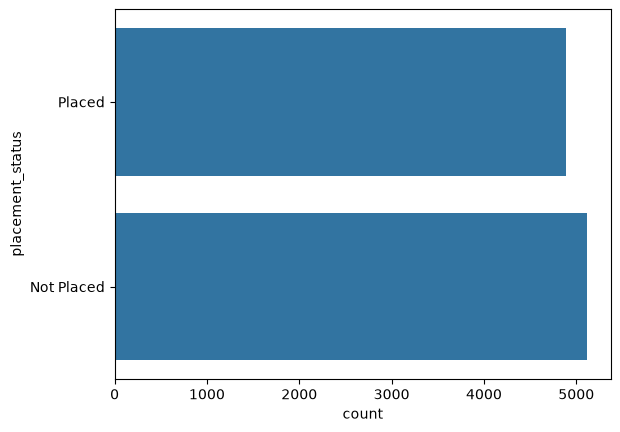

In [134]:
sns.countplot(df_copy['placement_status'])

#

### 2.4 Do placed students look different?
Let us compare the average of every number column for the two groups.

In [135]:
# Group by num_col to placement_status
num_col = df_copy.select_dtypes(include =np.number).columns
df_copy.groupby('placement_status')[num_col].mean()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score
placement_status,,,,,,,
Not Placed,2.890603,70.524177,6.775308,4.953032,10.478549,54.363594,51.830219
Placed,4.111519,81.249331,6.835060,4.015022,15.304430,69.512270,69.696233


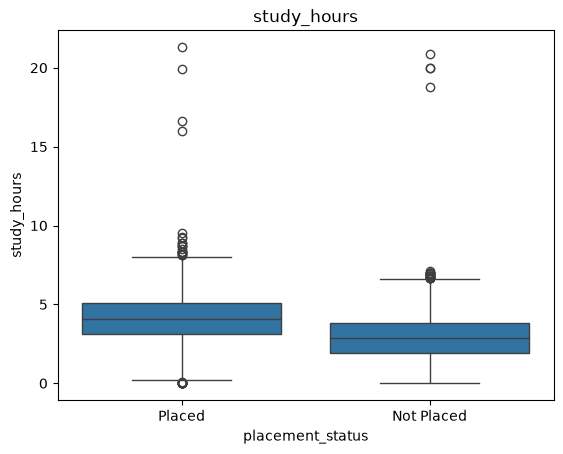

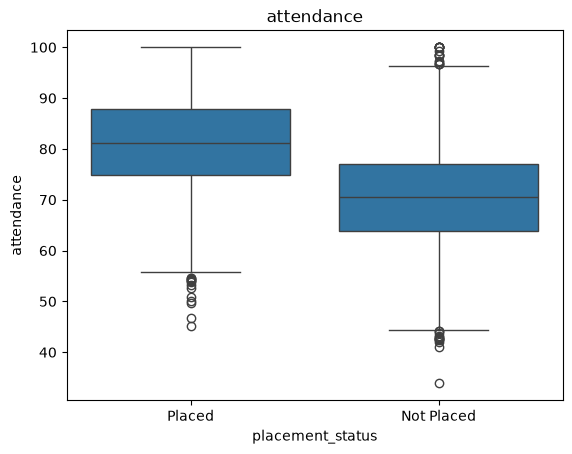

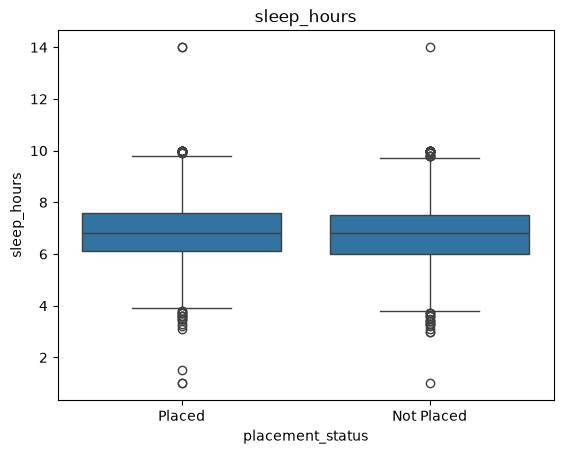

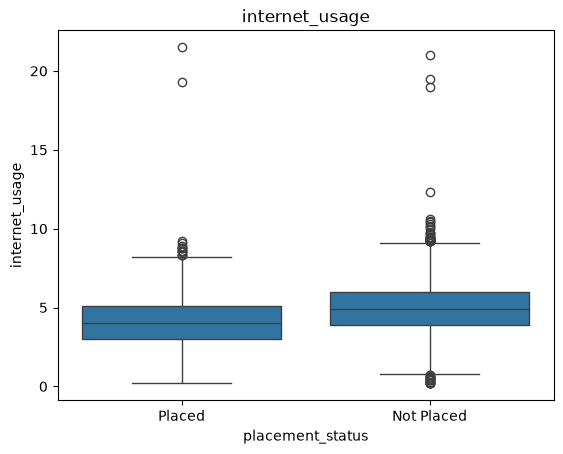

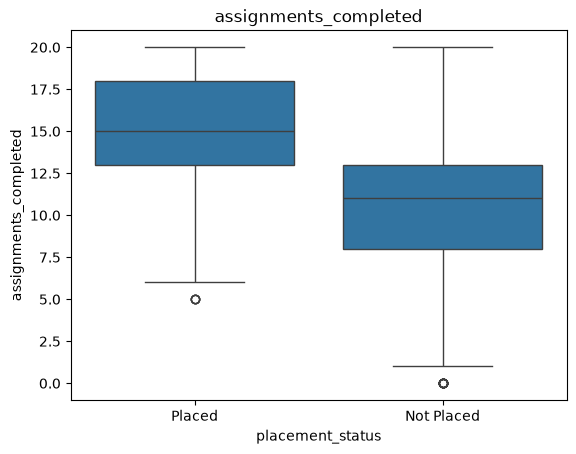

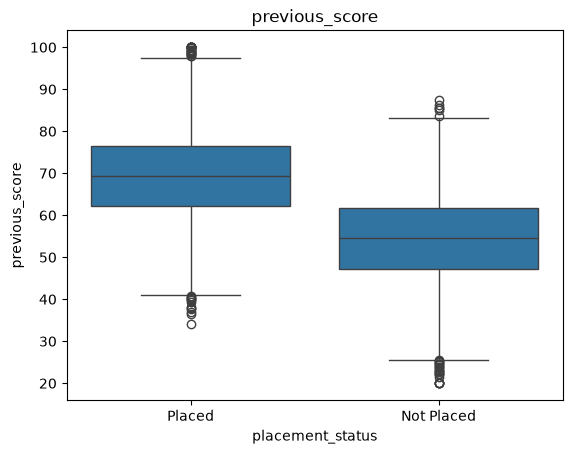

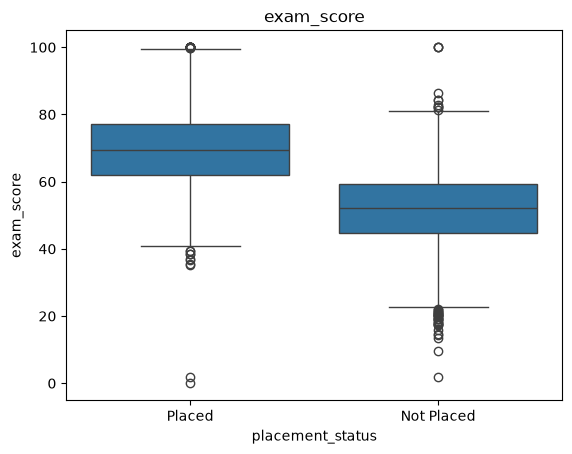

In [136]:
# Box plots: compare Placed and Not Placed for each number column
num_cols = df_copy.select_dtypes(include=np.number).columns

for col in num_cols:
    sns.boxplot(x="placement_status", y=col, data=df_copy)
    plt.title(col)
    plt.show()

<Axes: >

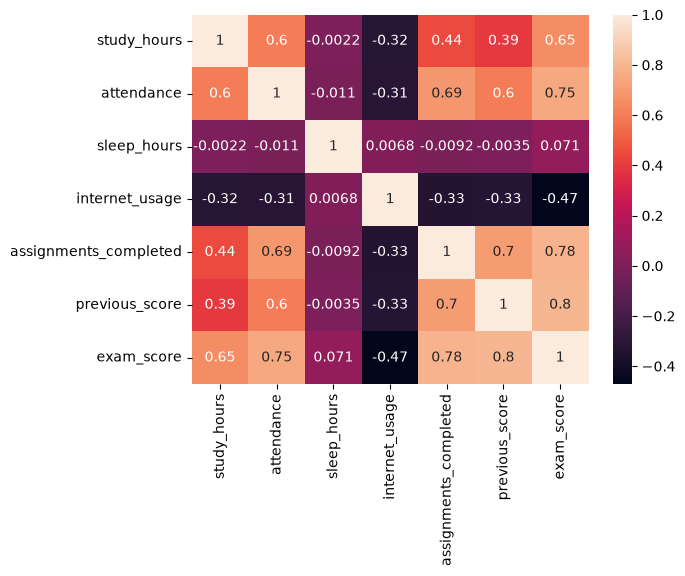

In [137]:
# Correlation: which number columns move together?
sns.heatmap(df_copy[num_col].corr(), annot = True)

---
## Step 3: Clean data

Rule: **never change the original data**. We work on a copy, so we can always go back.

We will do 5 cleaning jobs:
1. Remove duplicate rows
2. Drop `student_id` (it is only a label)
3. Fix the `gender` column
4. Fix the `branch` column
5. Fix impossible values (outliers)



In [138]:
# Make a copy so the original df stays safe

# Job 1: remove duplicate rows
df_copy.drop_duplicates(inplace = True)
df_copy.duplicated().sum()
# Job 1.0: Remove null values
df_copy.dropna(inplace=True)
df_copy.isnull().sum()

student_id               0
gender                   0
branch                   0
study_hours              0
attendance               0
sleep_hours              0
internet_usage           0
assignments_completed    0
previous_score           0
extracurricular          0
exam_score               0
placement_status         0
dtype: int64

In [139]:
# Job 2: student_id is only a label. It does not help to predict placement.
df_copy.drop(columns = ['student_id'], axis = 1, inplace = True)
df_copy.head(2)

,gender,branch,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,extracurricular,exam_score,placement_status
0,Female,Mechanical,1.5,68.2,6.7,2.6,15.0,63.6,Yes,60.8,Placed
1,Male,Mechanical,5.0,80.9,5.5,6.2,12.0,55.4,No,58.8,Not Placed


In [140]:
# Job 3: fix gender
# strip() removes extra spaces, lower() makes small letters, map() gives one clean name
df_copy['gender'] = df_copy['gender'].str.strip().str.lower().map({'male': 'male', 'female': 'female', 'm': 'male', 'f': 'female'})
df_copy['gender'].unique()

array(['female', 'male'], dtype=object)

In [141]:
# Job 4: fix branch
# Remove extra spaces and make everything CAPITAL letters, so ' cse ' becomes 'CSE'
df_copy['branch'] = df_copy['branch'].str.strip().str.upper()
df_copy['branch'].unique()

array(['MECHANICAL', 'IT', 'CSE', 'CIVIL', 'ECE', 'COMMERCE'],
      dtype=object)

In [142]:
# Job 5: fix impossible values with clip()
# clip(0, 12) means: anything above 12 becomes 12, anything below 0 becomes 0
df_copy["study_hours"] = df_copy["study_hours"].clip(0, 12)
df_copy["sleep_hours"] = df_copy["sleep_hours"].clip(3, 12)
df_copy["internet_usage"] = df_copy["internet_usage"].clip(0, 12)

df_copy[["study_hours", "sleep_hours", "internet_usage"]].describe().round(2)




,study_hours,sleep_hours,internet_usage
count,8139.00,8139.00,8139.00
mean,3.49,6.81,4.50
std,1.58,1.10,1.67
min,0.00,3.00,0.20
25%,2.40,6.10,3.40
50%,3.40,6.80,4.50
75%,4.50,7.60,5.60
max,12.00,12.00,12.00


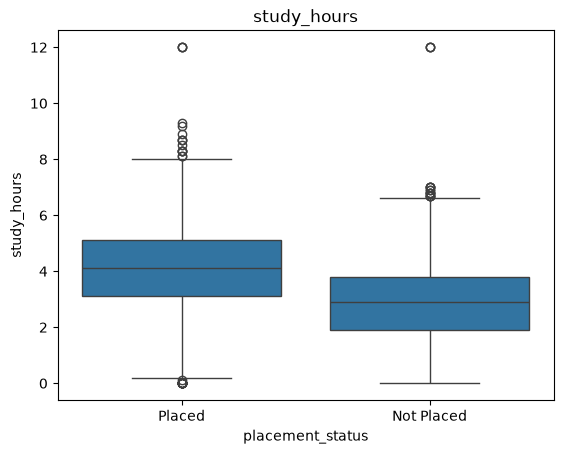

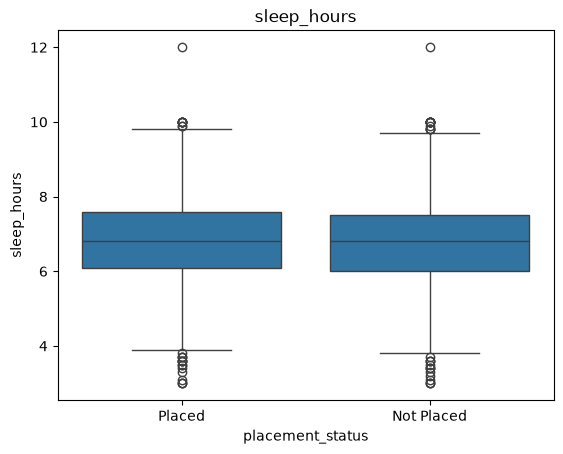

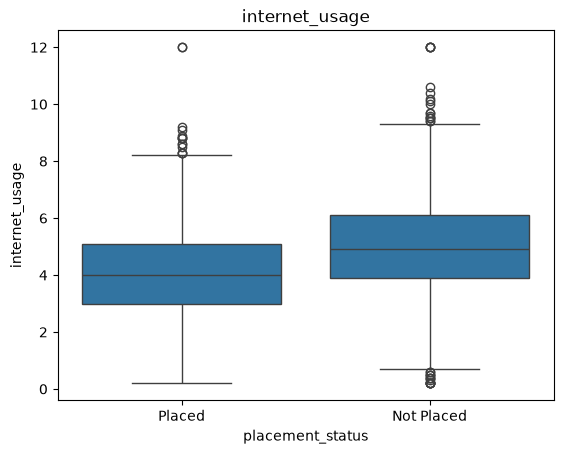

In [143]:
# Quick look at the cleaned categories
# Box plots: compare Placed and Not Placed for each number column
num_col = ['study_hours', 'sleep_hours', 'internet_usage']

for col in num_col:
    sns.boxplot(x="placement_status", y=col, data=df_copy)
    plt.title(col)
    plt.show()

Cleaning is done. Values are now consistent and there are no impossible numbers.
The missing values are still there. We fix them next.

---
## Step 4: Preprocessing

A decision tree needs clean numbers. Preprocessing has 4 small jobs:

1. **Separate X and y.** `X` = the inputs, `y` = the answer we want to predict.
2. **Split into train and test (80% / 20%).**
   *Real-life example:* Students learn from practice papers (train data) and the final exam (test data) has questions they have never seen. The test data tells us the truth.
3. **Convert text to numbers (one-hot encoding).**
   The column `branch` becomes separate columns like `branch_CSE = 1 or 0`, `branch_IT = 1 or 0`, and so on.

**Do we need scaling?** No. Decision trees ask questions like "attendance above 75?", so the scale of the numbers does not matter.

In [144]:
# 1. Convert text to numbers (one-hot encoding) on branch and others label encoding.
from sklearn.preprocessing import LabelEncoder

# Create a copy
df_copy = df_copy.copy()

# Branch → One-Hot Encoding
df_copy = pd.get_dummies(
    df_copy,
    columns=["branch"],
    dtype=int
)

# Label Encoding
label_en = LabelEncoder()

df_copy["gender"] = label_en.fit_transform(df_copy["gender"])
df_copy["extracurricular"] = label_en.fit_transform(df_copy["extracurricular"])
df_copy["placement_status"] = label_en.fit_transform(df_copy["placement_status"])

df_copy.head()

,gender,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,extracurricular,exam_score,placement_status,branch_CIVIL,branch_COMMERCE,branch_CSE,branch_ECE,branch_IT,branch_MECHANICAL
0,0,1.5,68.2,6.7,2.6,15.0,63.6,1,60.8,1,0,0,0,0,0,1
1,1,5.0,80.9,5.5,6.2,12.0,55.4,0,58.8,0,0,0,0,0,0,1
4,1,0.0,46.8,7.4,5.6,4.0,49.7,1,41.6,0,0,0,0,0,1,0
5,1,2.9,68.4,6.9,6.7,8.0,54.0,0,46.4,0,0,0,0,0,1,0
6,0,5.0,82.0,5.0,5.0,11.0,56.4,1,58.0,1,0,0,0,0,0,1


In [145]:
# 2. Separate X and y.
X = df_copy.drop(columns = ['placement_status'])
y = df_copy['placement_status']


In [146]:
# 3. Split into train and test (80% / 20%).
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(6511, 15)
(1628, 15)
(6511,)
(1628,)


---
## Step 5: Model
**Model : Default decision tree.**


In [147]:
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples

In [148]:
y_pred = clf.predict(X_test)

compare = pd.DataFrame({
    'Actul' : y_test,
    'Predicted' : y_pred
})
compare.head(10)


,Actul,Predicted
943,1,1
5035,1,1
1409,1,1
1023,1,0
1413,0,0
9910,0,0
5100,0,1
7405,1,0
3596,1,1
5888,0,1


In [149]:
from sklearn.metrics import accuracy_score
Test_acc = accuracy_score(y_test, clf.predict(X_test))
Train_acc = accuracy_score(y_train, clf.predict(X_train))
print(f'Train accuracy: {Train_acc}')
print(f'Test accuracy: {Test_acc}')

Train accuracy: 1.0
Test accuracy: 0.7426289926289926


---
## Step 6: Tune

Tuning means finding the best **settings** (hyperparameters) for the tree.

| Setting | Meaning | Real-life idea |
|---|---|---|
| `max_depth` | Maximum number of question levels | Limit an interview to 3 rounds |
| `min_samples_leaf` | Minimum students allowed in a final group | Do not make a rule from just 2 students |
| `criterion` | How to measure "messy" groups: `gini` or `entropy` | Two different rulers for the same job |

We train trees with depth 1, 2, 3 ... 15 and plot train vs test accuracy.

In [150]:
# 4. Define hyperparameters
param_grid = {
    'max_depth':[3,5,7,10],
    'min_samples_leaf':[1,2,5,10],
    'criterion':['gini','entropy']
}

In [151]:
# RandomizedSearch / gridSearchCV
from sklearn.model_selection import RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator = clf,
    param_distributions = param_grid,
    n_iter = 10,
    cv = 5,
    scoring = 'accuracy',
    random_state = 42
)

In [152]:
# Train
random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the a

In [153]:
# Best parameters
print(random_search.best_params_)

{'min_samples_leaf': 2, 'max_depth': 7, 'criterion': 'entropy'}


In [154]:
# Best Model
best_model = random_search.best_estimator_

In [155]:
# prediction
y_pred = best_model.predict(X_test)

In [156]:
# final accuracy score
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_pred))

0.8151105651105651


In [157]:
# Calculate and print train/test accuracy for the tuned (best) model
tuned_train_acc = accuracy_score(y_train, best_model.predict(X_train))
tuned_test_acc = accuracy_score(y_test, best_model.predict(X_test))

print(f'Tuned Model - Train Accuracy: {tuned_train_acc:.4f}')
print(f'Tuned Model - Test Accuracy: {tuned_test_acc:.4f}')

Tuned Model - Train Accuracy: 0.8352
Tuned Model - Test Accuracy: 0.8151


---
## Step 7: Evaluate

Now we test the tuned model on the **test data**, which it has never seen.

**Metrics in simple words** (think of "Placed" as the positive class):

| Metric | Question it answers |
|---|---|
| Accuracy | Out of all students, how many did we predict correctly? |
| Precision | Out of students we said "Placed", how many were really placed? |
| Recall | Out of students who were really placed, how many did we find? |
| F1-score | One number that balances precision and recall |


**Confusion matrix** is a 2x2 table that shows correct and wrong predictions of each type.

In [158]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
print(f'Accuracy : {accuracy_score(y_test, y_pred)  }')
print(f'Precision : {precision_score(y_test, y_pred)  }')
print(f'Recall : {recall_score(y_test, y_pred)  }')
print(f'F1-score : {f1_score(y_test, y_pred)  }')
print(f'Confusion matrix : \n{confusion_matrix(y_test, y_pred)  }')

Accuracy : 0.8151105651105651
Precision : 0.8382352941176471
Recall : 0.7769516728624535
F1-score : 0.8064308681672026
Confusion matrix : 
[[700 121]
 [180 627]]


gender                   0
study_hours              0
attendance               0
sleep_hours              0
internet_usage           0
assignments_completed    0
previous_score           0
extracurricular          0
exam_score               0
placement_status         0
branch_CIVIL             0
branch_COMMERCE          0
branch_CSE               0
branch_ECE               0
branch_IT                0
branch_MECHANICAL        0
dtype: int64

---
## Step 8: Explain

A big reason to use a decision tree is that we can **explain** its decisions.
A placement officer will not trust a model that only says "Placed" without a reason.

### Feature importance

C:\Users\vikas gour\AppData\Local\Temp\ipykernel_28388\2958553386.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


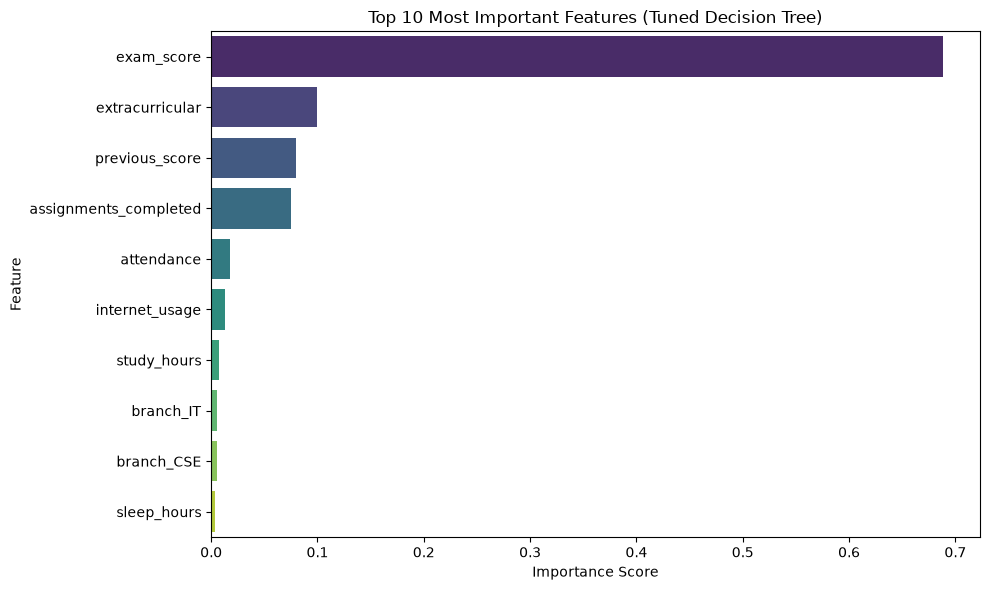

In [160]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get feature importances from our best model
importances = best_model.feature_importances_
features = X.columns

# Create a DataFrame for easy sorting and plotting
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot the top 10 most important features
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df.head(10),
    palette='viridis'
)
plt.title('Top 10 Most Important Features (Tuned Decision Tree)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Step 9: Save model


In [161]:
import joblib

# Save the trained best model to a file
model_filename = 'placement_model.joblib'
joblib.dump(best_model, model_filename)

print(f"Model successfully saved as '{model_filename}'!")

Model successfully saved as 'placement_model.joblib'!


In [162]:
import joblib
joblib.dump(X.columns.tolist(), 'columns.joblib')
print("✅ columns.joblib saved!")

✅ columns.joblib saved!


**Next: build the FastAPI app**
- `POST /predict` takes student details and returns Placed / Not Placed with the probability.
- A simple web page (HTML form) calls this API and shows the result.
- Keep `placement_model.joblib` and the same scikit-learn version in the API project.

#